# Fully equivariant holographic autoencoder v3
## Converging on one architecture with staged ablation and q-space reduction

This notebook replaces the broad v2 architecture comparison with one model
family: a **global spherical-Fourier (holographic) autoencoder**.  An unordered
18-neighbor environment is first represented as radial spherical-harmonic
coefficients.  The encoder, bottleneck, and decoder all carry O(3) irreducible
representations, so rotations pass through the complete model rather than
being removed by canonicalization, Kabsch alignment, FGW, or a distance-only
loss.

The final contract is

$$c(PXR^T)=\rho(R)c(X),$$
$$E(\rho(R)c)=\rho_z(R)E(c),$$
$$D(\rho_z(R)z)=\rho(R)D(z).$$
Because the representation matrices are orthogonal, the coefficient loss is
itself invariant:

$$\|\rho(R)\hat c-\rho(R)c\|_2^2=\|\hat c-c\|_2^2.$$

Thus orientation is preserved in the latent/output while the numerical loss
is independent of the chosen laboratory frame.

The decoded object is a smooth neighbor density in coefficient space.  This
avoids the fixed-slot obstruction encountered in v2: a symmetric unordered
point set can be invariant only after permuting particles, while a fixed list
of vector output slots cannot continuously perform that permutation.

The notebook performs:

1. leakage-safe frame splitting and a training-fitted radial basis;
2. exact coefficient and model equivariance audits;
3. staged screening of angular/radial resolution, latent width, nonlinear
   interaction, depth, loss balancing, and latent regularization;
4. full-data retraining of promoted finalists;
5. multi-seed confirmation of the validation-selected winner;
6. per-phase, per-degree, radial, density-map, and latent diagnostics;
7. equivariance-preserving irrep-wise PCA;
8. construction and dimensional ablation of a secondary q-like invariant
   space;
9. noise and missing-neighbor robustness tests.

Phase labels are never used for training, early stopping, architecture
promotion, or winner selection.  They are evaluation-only.

In [17]:
# Imports and reproducibility
import gc
import os
import random
import time
import warnings
from copy import deepcopy
from dataclasses import asdict, dataclass, replace
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    torch.serialization.add_safe_globals([slice])
except AttributeError:
    pass

import e3nn
from e3nn import o3
from e3nn.nn import NormActivation

warnings.filterwarnings(
    "ignore",
    message="The TorchScript type system doesn't support instance-level annotations.*",
    category=UserWarning,
)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("e3nn:", e3nn.__version__)

Device: cuda
PyTorch: 2.10.0+cu128
e3nn: 0.4.4


In [18]:
# Study configuration
PHASES = ("liquid", "fcc", "hcp")
LABEL_MAP = {phase: index for index, phase in enumerate(PHASES)}
LABEL_COLORS = {"liquid": "tab:green", "fcc": "tab:blue", "hcp": "tab:orange"}
DATA_FILENAME = "particle_data_second_shell.npz"
N_NEIGHBORS = 18
N_NODES = N_NEIGHBORS + 1

MAIN_SEED = 42
MAX_SAMPLES_PER_PHASE = 1_200
VAL_FRACTION = 0.20
TEST_FRACTION = 0.20

# A single master target makes every ablation directly comparable.
MASTER_LMAX = 6
MASTER_RADIAL_CHANNELS = 8
RADIAL_LOWER_QUANTILE = 0.001
RADIAL_UPPER_QUANTILE = 0.999

BATCH_SIZE = 128
SCREEN_EPOCHS = 24
SCREEN_PATIENCE = 6
SCREEN_TRAIN_PER_PHASE = 350
SCREEN_VAL_PER_PHASE = 150
FINAL_EPOCHS = 275
FINAL_PATIENCE = 40
FINALIST_COUNT = 2
LEARNING_RATE = 2e-3
MIN_LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-5
GRAD_CLIP = 5.0

RUN_SCREENING = False
RUN_FINALISTS = True
RUN_MULTI_SEED_CONFIRMATION = True
RUN_EQUIVARIANT_PCA = True
RUN_Q_SPACE_STUDY = True
RUN_CORRUPTION_AUDIT = True
CONFIRMATION_SEEDS = (42, 43, 44)

NOISE_LEVELS = (0.01, 0.03, 0.05, 0.10)
MASK_LEVELS = (0.10, 0.25, 0.40)
Q_DIMENSIONS = (2, 3, 4, 6, 8, 12, 16)
IRREP_PCA_ENERGY_LEVELS = (0.80, 0.90, 0.95, 0.99)

SMOKE_TEST = os.environ.get("AE_V3_SMOKE_TEST") == "1"
MAX_BATCHES = None
if SMOKE_TEST:
    MAX_SAMPLES_PER_PHASE = 24
    BATCH_SIZE = 24
    SCREEN_EPOCHS = 1
    SCREEN_PATIENCE = 1
    SCREEN_TRAIN_PER_PHASE = 8
    SCREEN_VAL_PER_PHASE = 6
    FINAL_EPOCHS = 1
    FINAL_PATIENCE = 1
    FINALIST_COUNT = 2
    CONFIRMATION_SEEDS = (42,)
    MAX_BATCHES = 1

print("Smoke test:", SMOKE_TEST)

Smoke test: False


## 1. Data and leakage-safe split

Only coordinates and frame indices are loaded.  Samples from the same
simulation frame never cross train/validation/test boundaries.  Coordinate
scaling and radial-basis endpoints are fitted using training frames only.

In [19]:
def locate_data_dir():
    candidates = (
        Path("."),
        Path("lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
        Path("autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples"),
    )
    for root in candidates:
        if all((root / phase / DATA_FILENAME).exists() for phase in PHASES):
            return root
    raise FileNotFoundError(f"Could not locate {DATA_FILENAME} for all phases")


def split_whole_frames(frame_indices, rng):
    frames = rng.permutation(np.unique(frame_indices))
    n_test = max(1, round(TEST_FRACTION * len(frames)))
    n_val = max(1, round(VAL_FRACTION * len(frames)))
    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, frames[:n_test])] = "test"
    split[np.isin(frame_indices, frames[n_test:n_test + n_val])] = "val"
    return split


def prepare_dataset(seed=MAIN_SEED):
    root = locate_data_dir()
    rng = np.random.default_rng(seed)
    raw = {}
    for phase in PHASES:
        with np.load(root / phase / DATA_FILENAME, allow_pickle=True) as npz:
            raw[phase] = {
                "vectors": np.asarray(npz["vec_dist"], dtype=np.float32),
                "frames": np.asarray(npz["frame_indices"], dtype=np.int64),
            }
        if raw[phase]["vectors"].shape[1:] != (N_NEIGHBORS, 3):
            raise ValueError(f"Unexpected coordinate shape for {phase}")

    n_per_phase = min(MAX_SAMPLES_PER_PHASE, *(len(raw[p]["vectors"]) for p in PHASES))
    coordinates, labels, splits, rows = [], [], [], []
    for phase in PHASES:
        selected = np.sort(rng.choice(len(raw[phase]["vectors"]), n_per_phase, replace=False))
        local_frames = raw[phase]["frames"][selected]
        local_split = split_whole_frames(local_frames, rng)
        center = np.zeros((n_per_phase, 1, 3), dtype=np.float32)
        coordinates.append(np.concatenate([center, raw[phase]["vectors"][selected]], axis=1))
        labels.append(np.full(n_per_phase, LABEL_MAP[phase], dtype=np.int64))
        splits.append(local_split)
        rows.append({
            "phase": phase,
            "samples": n_per_phase,
            **{
                f"{part}_frames": np.unique(local_frames[local_split == part]).size
                for part in ("train", "val", "test")
            },
        })

    coordinates = np.concatenate(coordinates)
    labels = np.concatenate(labels)
    split = np.concatenate(splits)
    train = split == "train"
    scale = float(np.median(np.linalg.norm(coordinates[train, 1:], axis=-1)))
    coordinates = (coordinates / scale).astype(np.float32)
    training_radii = np.linalg.norm(coordinates[train, 1:], axis=-1).ravel()
    radial_range = tuple(np.quantile(
        training_radii, [RADIAL_LOWER_QUANTILE, RADIAL_UPPER_QUANTILE]
    ).astype(float))
    return {
        "coordinates": coordinates,
        "labels": labels,
        "split": split,
        "coordinate_scale": scale,
        "radial_range": radial_range,
        "summary": pd.DataFrame(rows),
        "root": root,
    }


set_seed(MAIN_SEED)
dataset = prepare_dataset()
display(dataset["summary"])
print("Data:", dataset["root"].resolve())
print("Coordinate scale:", dataset["coordinate_scale"])
print("Training-fitted scaled radial range:", dataset["radial_range"])


def stratified_indices(dataset, split_name, per_phase, seed):
    rng = np.random.default_rng(seed)
    selected = []
    for phase in PHASES:
        candidates = np.flatnonzero(
            (dataset["split"] == split_name)
            & (dataset["labels"] == LABEL_MAP[phase])
        )
        count = min(per_phase, len(candidates))
        selected.append(rng.choice(candidates, count, replace=False))
    return np.sort(np.concatenate(selected))


screen_train_indices = stratified_indices(
    dataset, "train", SCREEN_TRAIN_PER_PHASE, MAIN_SEED + 1
)
screen_val_indices = stratified_indices(
    dataset, "val", SCREEN_VAL_PER_PHASE, MAIN_SEED + 2
)
full_train_indices = np.flatnonzero(dataset["split"] == "train")
full_val_indices = np.flatnonzero(dataset["split"] == "val")
test_indices = np.flatnonzero(dataset["split"] == "test")
print(
    "Screen/full sizes:", len(screen_train_indices), len(screen_val_indices),
    len(full_train_indices), len(full_val_indices), len(test_indices)
)

,phase,samples,train_frames,val_frames,test_frames
0,liquid,1200,176,58,58
1,fcc,1200,321,107,107
2,hcp,1200,308,102,102


Data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Coordinate scale: 1.1289727687835693
Training-fitted scaled radial range: (np.float64(0.7897800347208976), np.float64(1.5245496970415129))
Screen/full sizes: 1050 450 2137 724 739


## 2. Fixed spherical-Fourier representation

A neighbor density is expanded as

$$c_{nlm}(X)=\frac1N\sum_j g_n(r_j)Y_{lm}(\hat r_j).$$

Summation makes the representation permutation invariant.  Each degree-$l$
block transforms through its Wigner matrix and is therefore equivariant.  A
common eight-channel, $l_{max}=6$ target is used for every candidate.  Lower
resolution candidates see only selected radial channels and/or angular
degrees but must reconstruct the same master target.

In [20]:
def parity_for_degree(degree):
    return "e" if degree % 2 == 0 else "o"


def coefficient_irreps(n_radial, lmax):
    return o3.Irreps(" + ".join(
        f"{n_radial}x{degree}{parity_for_degree(degree)}"
        for degree in range(lmax + 1)
    ))


MASTER_IRREPS = coefficient_irreps(MASTER_RADIAL_CHANNELS, MASTER_LMAX)


class SphericalNeighborExpansion(nn.Module):
    def __init__(self, radial_range):
        super().__init__()
        lower, upper = radial_range
        self.irreps = MASTER_IRREPS
        self.register_buffer(
            "centers", torch.linspace(lower, upper, MASTER_RADIAL_CHANNELS)
        )
        spacing = float((upper - lower) / max(1, MASTER_RADIAL_CHANNELS - 1))
        self.gamma = 1.0 / max(spacing, 1e-3) ** 2

    def forward(self, coordinates, observed=None):
        points = coordinates[:, 1:]
        radii = points.norm(dim=-1, keepdim=True)
        radial = torch.exp(-self.gamma * (radii - self.centers).square())
        if observed is not None:
            radial = radial * observed[:, 1:]
        blocks = []
        for degree in range(MASTER_LMAX + 1):
            harmonics = o3.spherical_harmonics(
                degree, points, normalize=True, normalization="component"
            )
            block = torch.einsum("bnr,bnm->brm", radial, harmonics) / N_NEIGHBORS
            blocks.append(block.flatten(1))
        return torch.cat(blocks, dim=-1)

    def angular_power(self, coefficients):
        powers = []
        for (multiplicity, irrep), slc in zip(self.irreps, self.irreps.slices()):
            block = coefficients[:, slc].reshape(len(coefficients), multiplicity, irrep.dim)
            powers.append(block.square().sum(dim=-1).mean(dim=-1).clamp_min(0).sqrt())
        return torch.stack(powers, dim=-1)


def expansion_numpy(coordinates, expansion, observed=None, batch_size=BATCH_SIZE):
    expansion = expansion.to(DEVICE)
    values = []
    with torch.no_grad():
        for start in range(0, len(coordinates), batch_size):
            batch = torch.from_numpy(coordinates[start:start + batch_size]).to(DEVICE)
            batch_observed = None
            if observed is not None:
                batch_observed = torch.from_numpy(
                    observed[start:start + batch_size]
                ).to(DEVICE)
            values.append(expansion(batch, batch_observed).cpu().numpy())
    return np.concatenate(values)


master_expansion = SphericalNeighborExpansion(dataset["radial_range"])
master_coefficients = expansion_numpy(dataset["coordinates"], master_expansion)
print("Master coefficient irreps:", MASTER_IRREPS)
print("Master coefficient dimension:", MASTER_IRREPS.dim)
print("Precomputed coefficient array:", master_coefficients.shape)


def random_rotation_matrices(batch_size, device, generator):
    quaternion = torch.randn(batch_size, 4, device=device, generator=generator)
    quaternion = quaternion / quaternion.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    w, x, y, z = quaternion.unbind(-1)
    return torch.stack([
        1 - 2 * (y*y + z*z), 2 * (x*y - z*w), 2 * (x*z + y*w),
        2 * (x*y + z*w), 1 - 2 * (x*x + z*z), 2 * (y*z - x*w),
        2 * (x*z - y*w), 2 * (y*z + x*w), 1 - 2 * (x*x + y*y),
    ], dim=-1).reshape(batch_size, 3, 3)


def include_reflections(rotations):
    """Turn alternating SO(3) samples into O(3) samples for parity audits."""
    reflections = torch.eye(3, device=rotations.device).repeat(len(rotations), 1, 1)
    reflections[::2, 0, 0] = -1.0
    return rotations @ reflections


def rotate_irrep_features(features, irreps, rotations):
    matrices = irreps.D_from_matrix(rotations).to(features.dtype)
    return torch.einsum("bij,bj->bi", matrices, features)


def expansion_equivariance_audit(expansion, dataset):
    coordinates = torch.from_numpy(dataset["coordinates"][:16]).to(DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(MAIN_SEED + 500)
    rotations = include_reflections(
        random_rotation_matrices(len(coordinates), DEVICE, generator)
    )
    permutation = torch.argsort(
        torch.rand(len(coordinates), N_NEIGHBORS, device=DEVICE, generator=generator),
        dim=1,
    ) + 1
    permutation = torch.cat([
        torch.zeros(len(coordinates), 1, dtype=torch.long, device=DEVICE),
        permutation,
    ], dim=1)
    permuted = torch.gather(
        coordinates, 1, permutation.unsqueeze(-1).expand(-1, -1, 3)
    )
    transformed = permuted @ rotations.transpose(-1, -2)
    expansion = expansion.to(DEVICE)
    with torch.no_grad():
        reference = expansion(coordinates)
        actual = expansion(transformed)
        expected = rotate_irrep_features(reference, expansion.irreps, rotations)
    return float((actual - expected).abs().max().item())


print("Expansion rotation+permutation max error:", expansion_equivariance_audit(
    master_expansion, dataset
))

Master coefficient irreps: 8x0e+8x1o+8x2e+8x3o+8x4e+8x5o+8x6e
Master coefficient dimension: 392
Precomputed coefficient array: (3600, 392)
Expansion rotation+permutation max error: 9.313225746154785e-07


## 3. Holographic autoencoder family

The only model family below is a global irrep autoencoder.  Ablations change
how much of the master expansion is observed, the multiplicity of each latent
irrep, and how angular degrees interact.

- `spectral_gate`: channel mixing at fixed $l$, followed by gates constructed
  from invariant irrep norms;
- `tensor_product`: learned Clebsch–Gordan tensor products couple angular
  degrees;
- `hybrid`: a tensor-product residual followed by spectral gating.

In [21]:
WIDTH_PROFILES = {
    "tiny": {0: 3, 1: 2, 2: 1},
    "small": {0: 4, 1: 2, 2: 2, 3: 1, 4: 1},
    "medium": {0: 8, 1: 4, 2: 4, 3: 2, 4: 2, 5: 1, 6: 1},
    "large": {0: 12, 1: 6, 2: 6, 3: 3, 4: 3, 5: 2, 6: 2},
}


def latent_irreps_for_width(width):
    multiplicities = WIDTH_PROFILES[width]
    return o3.Irreps(" + ".join(
        f"{multiplicity}x{degree}{parity_for_degree(degree)}"
        for degree, multiplicity in multiplicities.items()
        if multiplicity > 0
    ))


def invariant_channel_values(features, irreps):
    values = []
    for (multiplicity, irrep), slc in zip(irreps, irreps.slices()):
        block = features[:, slc].reshape(len(features), multiplicity, irrep.dim)
        if irrep.l == 0:
            values.append(block.squeeze(-1))
        else:
            values.append(block.square().sum(dim=-1).clamp_min(1e-12).sqrt())
    return torch.cat(values, dim=-1)


class SpectralGateBlock(nn.Module):
    def __init__(self, irreps):
        super().__init__()
        self.irreps = o3.Irreps(irreps)
        self.linear = o3.Linear(self.irreps, self.irreps)
        channels = sum(multiplicity for multiplicity, _ in self.irreps)
        self.gate = nn.Sequential(
            nn.Linear(channels, 2 * channels), nn.SiLU(), nn.Linear(2 * channels, channels)
        )

    def forward(self, features):
        mixed = self.linear(features)
        invariants = invariant_channel_values(mixed, self.irreps)
        gates = torch.sigmoid(self.gate(invariants))
        blocks, offset = [], 0
        for (multiplicity, irrep), slc in zip(self.irreps, self.irreps.slices()):
            block = mixed[:, slc].reshape(len(features), multiplicity, irrep.dim)
            blocks.append((block * gates[:, offset:offset + multiplicity, None]).flatten(1))
            offset += multiplicity
        return features + torch.cat(blocks, dim=-1)


class TensorProductBlock(nn.Module):
    def __init__(self, irreps):
        super().__init__()
        self.irreps = o3.Irreps(irreps)
        self.tensor_product = o3.FullyConnectedTensorProduct(
            self.irreps, self.irreps, self.irreps
        )
        self.skip = o3.Linear(self.irreps, self.irreps)
        self.activation = NormActivation(self.irreps, F.silu)

    def forward(self, features):
        return self.activation(
            self.skip(features) + self.tensor_product(features, features)
        )


class HybridBlock(nn.Module):
    def __init__(self, irreps):
        super().__init__()
        self.tensor_product = TensorProductBlock(irreps)
        self.spectral_gate = SpectralGateBlock(irreps)

    def forward(self, features):
        return self.spectral_gate(self.tensor_product(features))


BLOCK_FACTORIES = {
    "spectral_gate": SpectralGateBlock,
    "tensor_product": TensorProductBlock,
    "hybrid": HybridBlock,
}


@dataclass(frozen=True)
class ModelSpec:
    name: str
    group: str = "reference"
    input_lmax: int = 6
    input_radial_channels: int = 8
    width: str = "medium"
    block_type: str = "hybrid"
    depth: int = 2
    loss_type: str = "hybrid"
    latent_regularization: float = 0.0


def radial_selection(count):
    return np.unique(np.round(
        np.linspace(0, MASTER_RADIAL_CHANNELS - 1, count)
    ).astype(int))


def master_subset_indices(input_lmax, input_radial_channels):
    radial_indices = radial_selection(input_radial_channels)
    selected = []
    for (multiplicity, irrep), slc in zip(MASTER_IRREPS, MASTER_IRREPS.slices()):
        if irrep.l > input_lmax:
            continue
        block = np.arange(slc.start, slc.stop).reshape(multiplicity, irrep.dim)
        selected.extend(block[radial_indices].ravel().tolist())
    return np.asarray(selected, dtype=np.int64)


class HolographicAutoencoder(nn.Module):
    def __init__(self, spec):
        super().__init__()
        self.spec = spec
        self.output_irreps = MASTER_IRREPS
        self.latent_irreps = latent_irreps_for_width(spec.width)
        self.input_irreps = coefficient_irreps(
            spec.input_radial_channels, spec.input_lmax
        )
        self.register_buffer(
            "input_indices",
            torch.from_numpy(master_subset_indices(
                spec.input_lmax, spec.input_radial_channels
            )),
        )
        self.input_projection = o3.Linear(self.input_irreps, self.latent_irreps)
        block_factory = BLOCK_FACTORIES[spec.block_type]
        self.encoder_blocks = nn.ModuleList([
            block_factory(self.latent_irreps) for _ in range(spec.depth)
        ])
        self.decoder_blocks = nn.ModuleList([
            block_factory(self.latent_irreps) for _ in range(spec.depth)
        ])
        self.output_projection = o3.Linear(self.latent_irreps, self.output_irreps)

    def encode(self, master_coefficients):
        latent = self.input_projection(master_coefficients[:, self.input_indices])
        for block in self.encoder_blocks:
            latent = block(latent)
        return latent

    def decode(self, latent):
        hidden = latent
        for block in self.decoder_blocks:
            hidden = block(hidden)
        return self.output_projection(hidden)

    def forward(self, master_coefficients):
        latent = self.encode(master_coefficients)
        return self.decode(latent), latent


def model_summary(spec):
    model = HolographicAutoencoder(spec)
    return {
        **asdict(spec),
        "input_dimension": model.input_irreps.dim,
        "latent_dimension": model.latent_irreps.dim,
        "latent_channels": sum(multiplicity for multiplicity, _ in model.latent_irreps),
        "parameters": sum(parameter.numel() for parameter in model.parameters()),
    }

## 4. Comparable objectives and evaluation metrics

Candidate training objectives differ, but promotion always uses the same
label-free score: one half global relative RMSE and one half the mean relative
RMSE across angular degrees.  This prevents a candidate from winning merely
by fitting the energetic scalar block while ignoring weak, high-$l$ structure.

In [22]:
def degree_slices(irreps=MASTER_IRREPS):
    return [
        (irrep.l, slc) for (_, irrep), slc in zip(irreps, irreps.slices())
    ]


def global_relative_mse(prediction, target):
    numerator = (prediction - target).square().mean()
    denominator = target.square().mean().detach().clamp_min(1e-6)
    return numerator / denominator


def balanced_degree_mse(prediction, target):
    global_energy = target.square().mean().detach()
    losses = []
    for _, slc in degree_slices():
        numerator = (prediction[:, slc] - target[:, slc]).square().mean()
        denominator = target[:, slc].square().mean().detach()
        denominator = denominator.clamp_min(0.02 * global_energy).clamp_min(1e-6)
        losses.append(numerator / denominator)
    return torch.stack(losses).mean()


def reconstruction_objective(prediction, target, loss_type):
    global_loss = global_relative_mse(prediction, target)
    balanced_loss = balanced_degree_mse(prediction, target)
    if loss_type == "global":
        return global_loss
    if loss_type == "balanced_degree":
        return balanced_loss
    if loss_type == "hybrid":
        return 0.5 * global_loss + 0.5 * balanced_loss
    raise KeyError(loss_type)


def irrep_variance_covariance_penalty(latent, irreps):
    invariants = invariant_channel_values(latent, irreps)
    centered = invariants - invariants.mean(dim=0, keepdim=True)
    standard_deviation = torch.sqrt(centered.var(dim=0, unbiased=False) + 1e-4)
    variance = torch.relu(0.05 - standard_deviation).square().mean()
    normalized = centered / standard_deviation.clamp_min(1e-4)
    covariance = normalized.T @ normalized / max(1, len(latent) - 1)
    off_diagonal = covariance - torch.diag(torch.diag(covariance))
    decorrelation = off_diagonal.square().sum() / max(1, latent.shape[-1])
    return variance + decorrelation


def relative_rmse_per_sample(prediction, target):
    return torch.sqrt(
        (prediction - target).square().sum(dim=-1)
        / target.square().sum(dim=-1).clamp_min(1e-12)
    )


def relative_rmse_by_degree(prediction, target):
    result = {}
    for degree, slc in degree_slices():
        value = relative_rmse_per_sample(prediction[:, slc], target[:, slc])
        result[degree] = value
    return result


def selection_score_per_sample(prediction, target):
    global_error = relative_rmse_per_sample(prediction, target)
    degree_errors = torch.stack(list(
        relative_rmse_by_degree(prediction, target).values()
    ), dim=-1).mean(dim=-1)
    return 0.5 * global_error + 0.5 * degree_errors

## 5. Training harness

Screening uses a balanced subset and short schedules.  Finalists are rebuilt
from scratch on every training frame.  Early stopping and promotion use only
validation reconstruction error.

In [23]:
def coefficient_loader(coefficients, indices, seed, shuffle):
    return DataLoader(
        TensorDataset(torch.from_numpy(coefficients[indices])),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed) if shuffle else None,
        num_workers=0,
    )


def run_epoch(model, loader, optimizer, seed):
    training = optimizer is not None
    model.train(training)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    totals = {
        "objective": 0.0, "global_rmse": 0.0, "selection_score": 0.0,
        "balanced_loss": 0.0, "regularization": 0.0,
    }
    count = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch_index, (target,) in enumerate(loader):
            target = target.to(DEVICE)
            if training:
                rotations = random_rotation_matrices(len(target), DEVICE, generator)
                target = rotate_irrep_features(target, MASTER_IRREPS, rotations)
                optimizer.zero_grad(set_to_none=True)
            prediction, latent = model(target)
            reconstruction = reconstruction_objective(
                prediction, target, model.spec.loss_type
            )
            regularization = irrep_variance_covariance_penalty(
                latent, model.latent_irreps
            )
            objective = reconstruction + model.spec.latent_regularization * regularization
            if training:
                objective.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            batch_values = {
                "objective": objective.item(),
                "global_rmse": relative_rmse_per_sample(prediction, target).mean().item(),
                "selection_score": selection_score_per_sample(prediction, target).mean().item(),
                "balanced_loss": balanced_degree_mse(prediction, target).item(),
                "regularization": regularization.item(),
            }
            for key, value in batch_values.items():
                totals[key] += value * len(target)
            count += len(target)
            if MAX_BATCHES is not None and batch_index + 1 >= MAX_BATCHES:
                break
    return {key: value / count for key, value in totals.items()}


def predict_coefficients_and_latent(model, coefficients, indices=None):
    if indices is None:
        indices = np.arange(len(coefficients))
    model = model.to(DEVICE).eval()
    predictions, latents = [], []
    with torch.no_grad():
        for start in range(0, len(indices), BATCH_SIZE):
            local_indices = indices[start:start + BATCH_SIZE]
            target = torch.from_numpy(coefficients[local_indices]).to(DEVICE)
            prediction, latent = model(target)
            predictions.append(prediction.cpu().numpy())
            latents.append(latent.cpu().numpy())
    model.cpu()
    return np.concatenate(predictions), np.concatenate(latents)


def train_candidate(
    spec, coefficients, train_indices, val_indices, seed,
    max_epochs, patience, verbose=False,
):
    set_seed(seed)
    model = HolographicAutoencoder(spec).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max_epochs, eta_min=MIN_LEARNING_RATE
    )
    train_loader = coefficient_loader(coefficients, train_indices, seed, True)
    val_loader = coefficient_loader(coefficients, val_indices, seed, False)
    history, best_state = [], None
    best_value, best_epoch, stale = np.inf, -1, 0
    started = time.perf_counter()
    for epoch in range(max_epochs):
        train_metrics = run_epoch(
            model, train_loader, optimizer, seed * 10_000 + epoch
        )
        val_metrics = run_epoch(
            model, val_loader, None, seed * 10_000 + 9_999
        )
        history.append({
            "epoch": epoch + 1,
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })
        selection_value = val_metrics["selection_score"]
        if selection_value < best_value - 1e-6:
            best_value = selection_value
            best_epoch = epoch + 1
            best_state = deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
        if verbose and (epoch == 0 or (epoch + 1) % 25 == 0):
            print(
                f"  epoch={epoch + 1:03d} "
                f"train_RRMSE={train_metrics['global_rmse']:.4f} "
                f"val_RRMSE={val_metrics['global_rmse']:.4f} "
                f"selection={val_metrics['selection_score']:.4f} "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )
        scheduler.step()
        if stale >= patience:
            break
    model.load_state_dict(best_state)
    runtime = time.perf_counter() - started
    validation_prediction, validation_latent = predict_coefficients_and_latent(
        model, coefficients, val_indices
    )
    validation_target = coefficients[val_indices]
    validation_scores = selection_score_per_sample(
        torch.from_numpy(validation_prediction), torch.from_numpy(validation_target)
    ).numpy()
    per_degree = relative_rmse_by_degree(
        torch.from_numpy(validation_prediction), torch.from_numpy(validation_target)
    )
    row = {
        **model_summary(spec),
        "seed": seed,
        "validation_selection_score": float(validation_scores.mean()),
        "validation_selection_standard_error": float(
            validation_scores.std(ddof=1) / np.sqrt(len(validation_scores))
        ) if len(validation_scores) > 1 else 0.0,
        "best_epoch": best_epoch,
        "validation_global_RRMSE": float(np.mean(np.sqrt(
            np.square(validation_prediction - validation_target).sum(axis=1)
            / np.square(validation_target).sum(axis=1).clip(min=1e-12)
        ))),
        "runtime_seconds": runtime,
        **{
            f"validation_l{degree}_RRMSE": float(values.mean())
            for degree, values in per_degree.items()
        },
    }
    artifact = {
        "spec": spec,
        "seed": seed,
        "model": model,
        "history": pd.DataFrame(history),
        "summary": row,
        "validation_latent": validation_latent,
        "validation_selection_scores": validation_scores,
    }
    return artifact

## 6. Stage-one ablation screen

This is a structured one-factor screen around a medium hybrid reference, not
a prohibitively large Cartesian product.  The screen asks:

- Is information through $l=6$ needed?
- How many radial observations are useful?
- How narrow can the global latent be?
- Are Clebsch–Gordan interactions necessary?
- How much nonlinear depth is useful?
- Which coefficient-loss normalization generalizes best?
- Does latent variance/covariance regularization help?

In [24]:
BASE_SPEC = ModelSpec(name="reference")


def variant(name, group, **updates):
    return replace(BASE_SPEC, name=name, group=group, **updates)


SCREENING_SPECS = [
    BASE_SPEC,
    variant("resolution_l2_r4", "resolution", input_lmax=2, input_radial_channels=4),
    variant("resolution_l4_r4", "resolution", input_lmax=4, input_radial_channels=4),
    variant("resolution_l4_r8", "resolution", input_lmax=4, input_radial_channels=8),
    variant("resolution_l6_r4", "resolution", input_lmax=6, input_radial_channels=4),
    variant("width_tiny", "capacity", width="tiny"),
    variant("width_small", "capacity", width="small"),
    variant("width_large", "capacity", width="large"),
    variant("block_spectral_gate", "interaction", block_type="spectral_gate"),
    variant("block_tensor_product", "interaction", block_type="tensor_product"),
    variant("depth_1", "depth", depth=1),
    variant("depth_3", "depth", depth=3),
    variant("loss_global", "loss", loss_type="global"),
    variant("loss_balanced", "loss", loss_type="balanced_degree"),
    variant("latent_reg_1e4", "regularization", latent_regularization=1e-4),
    variant("latent_reg_1e3", "regularization", latent_regularization=1e-3),
]

# Focused exploitation: isolate the unresolved loss choice on the selected backbone.
EXPLOITATION_SPECS = [
    variant(
        "large_depth1_global", "exploitation",
        width="large", depth=1, loss_type="global",
    ),
    variant(
        "large_depth1_hybrid", "exploitation",
        width="large", depth=1, loss_type="hybrid",
    ),
]

if SMOKE_TEST:
    smoke_names = {
        "reference", "resolution_l2_r4", "width_small",
        "block_spectral_gate", "block_tensor_product", "loss_global",
    }
    SCREENING_SPECS = [
        spec for spec in SCREENING_SPECS if spec.name in smoke_names
    ]

ACTIVE_SPECS = SCREENING_SPECS if RUN_SCREENING else EXPLOITATION_SPECS
display(pd.DataFrame([model_summary(spec) for spec in ACTIVE_SPECS]))


screening_artifacts = {}
if RUN_SCREENING:
    for spec in SCREENING_SPECS:
        print(f"\nScreening | {spec.name}")
        artifact = train_candidate(
            spec, master_coefficients,
            screen_train_indices, screen_val_indices,
            MAIN_SEED, SCREEN_EPOCHS, SCREEN_PATIENCE,
        )
        screening_artifacts[spec.name] = artifact
        print(
            f"  best epoch={artifact['summary']['best_epoch']} "
            f"val RRMSE={artifact['summary']['validation_global_RRMSE']:.4f} "
            f"selection={artifact['summary']['validation_selection_score']:.4f}"
        )
        gc.collect()

    screening_results = pd.DataFrame([
        artifact["summary"] for artifact in screening_artifacts.values()
    ]).sort_values("validation_selection_score").reset_index(drop=True)
    display(screening_results.round(5))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ordered = screening_results.sort_values("validation_selection_score")
    axes[0].barh(
        ordered["name"], ordered["validation_selection_score"],
        color=plt.cm.tab10(pd.Categorical(ordered["group"]).codes)
    )
    axes[0].invert_yaxis()
    axes[0].set(xlabel="validation selection score", title="Stage-one ranking")
    axes[0].grid(axis="x", alpha=0.2)
    for group, frame in screening_results.groupby("group"):
        axes[1].scatter(
            frame["parameters"], frame["validation_global_RRMSE"],
            s=55, alpha=0.8, label=group
        )
    axes[1].set(
        xlabel="trainable parameters", ylabel="validation global relative RMSE",
        title="Accuracy–capacity tradeoff"
    )
    axes[1].grid(alpha=0.2)
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

,name,group,input_lmax,input_radial_channels,width,block_type,depth,loss_type,latent_regularization,input_dimension,latent_dimension,latent_channels,parameters
0,large_depth1_global,exploitation,6,8,large,hybrid,1,global,0.0,392,156,34,29316
1,large_depth1_hybrid,exploitation,6,8,large,hybrid,1,hybrid,0.0,392,156,34,29316


## 7. Promotion and full-data finalists

The top validation-score candidates are promoted.  A composed candidate also takes
each factor change that beat the reference and combines them, testing whether
individually useful choices remain useful together.  Winner selection remains
label-free.

Focused exploitation configurations


,name,group,input_lmax,input_radial_channels,width,block_type,depth,loss_type,latent_regularization,input_dimension,latent_dimension,latent_channels,parameters
0,large_depth1_global,exploitation,6,8,large,hybrid,1,global,0.0,392,156,34,29316
1,large_depth1_hybrid,exploitation,6,8,large,hybrid,1,hybrid,0.0,392,156,34,29316



Full-data finalist | full__large_depth1_global
  epoch=001 train_RRMSE=0.9490 val_RRMSE=0.9120 selection=0.9296 lr=2.00e-03
  epoch=025 train_RRMSE=0.4519 val_RRMSE=0.4585 selection=0.4415 lr=1.96e-03
  epoch=050 train_RRMSE=0.3871 val_RRMSE=0.3941 selection=0.3706 lr=1.85e-03
  epoch=075 train_RRMSE=0.3684 val_RRMSE=0.3751 selection=0.3492 lr=1.67e-03
  epoch=100 train_RRMSE=0.3624 val_RRMSE=0.3690 selection=0.3412 lr=1.43e-03
  epoch=125 train_RRMSE=0.3602 val_RRMSE=0.3668 selection=0.3375 lr=1.16e-03
  epoch=150 train_RRMSE=0.3593 val_RRMSE=0.3659 selection=0.3354 lr=8.80e-04
  epoch=175 train_RRMSE=0.3588 val_RRMSE=0.3653 selection=0.3340 lr=6.09e-04
  epoch=200 train_RRMSE=0.3585 val_RRMSE=0.3650 selection=0.3332 lr=3.70e-04
  epoch=225 train_RRMSE=0.3583 val_RRMSE=0.3649 selection=0.3327 lr=1.83e-04
  epoch=250 train_RRMSE=0.3582 val_RRMSE=0.3648 selection=0.3324 lr=6.34e-05
  epoch=275 train_RRMSE=0.3582 val_RRMSE=0.3648 selection=0.3324 lr=2.01e-05

Full-data finalist | full__

,name,group,input_lmax,input_radial_channels,width,block_type,depth,loss_type,latent_regularization,input_dimension,...,best_epoch,validation_global_RRMSE,runtime_seconds,validation_l0_RRMSE,validation_l1_RRMSE,validation_l2_RRMSE,validation_l3_RRMSE,validation_l4_RRMSE,validation_l5_RRMSE,validation_l6_RRMSE
0,full__large_depth1_hybrid,finalist,6,8,large,hybrid,1,hybrid,0.0,392,...,275,0.36454,637.02377,0.03146,0.20026,0.17369,0.42509,0.36432,0.48840,0.39744
1,full__large_depth1_global,finalist,6,8,large,hybrid,1,global,0.0,392,...,274,0.36478,649.30461,0.02936,0.19984,0.19609,0.42503,0.36366,0.48839,0.39735


Numerically best validation architecture: full__large_depth1_hybrid
One-standard-error selected architecture: full__large_depth1_hybrid
One-standard-error limit: 0.3329121910233652
{'name': 'full__large_depth1_hybrid', 'group': 'finalist', 'input_lmax': 6, 'input_radial_channels': 8, 'width': 'large', 'block_type': 'hybrid', 'depth': 1, 'loss_type': 'hybrid', 'latent_regularization': 0.0}


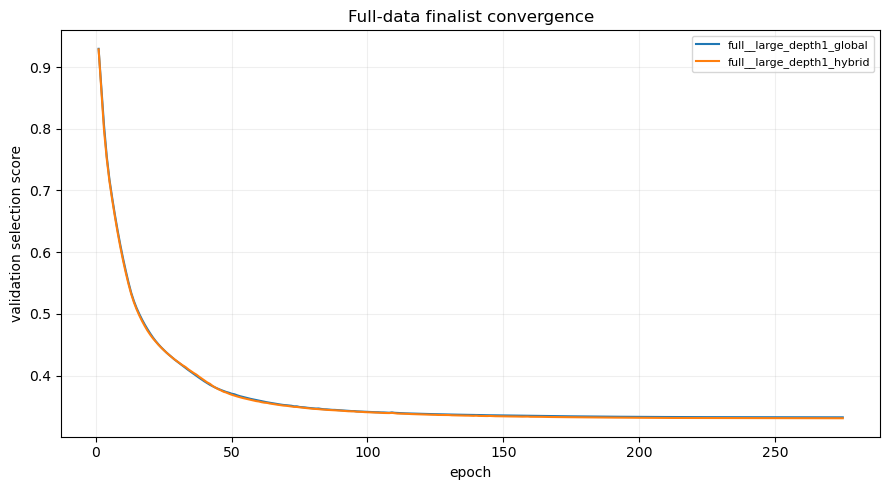

In [25]:
def spec_signature(spec):
    values = asdict(spec).copy()
    values.pop("name")
    values.pop("group")
    return tuple(sorted(values.items()))


def compose_factor_winner(screening_results):
    composed = BASE_SPEC
    reference_score = float(screening_results.loc[
        screening_results["name"] == BASE_SPEC.name,
        "validation_selection_score",
    ].iloc[0])
    fields_by_group = {
        "resolution": ("input_lmax", "input_radial_channels"),
        "capacity": ("width",),
        "interaction": ("block_type",),
        "depth": ("depth",),
        "loss": ("loss_type",),
        "regularization": ("latent_regularization",),
    }
    specs_by_name = {spec.name: spec for spec in SCREENING_SPECS}
    adopted = []
    for group, fields in fields_by_group.items():
        candidates = screening_results[screening_results["group"] == group]
        if candidates.empty:
            continue
        winner = candidates.sort_values("validation_selection_score").iloc[0]
        if float(winner["validation_selection_score"]) < reference_score:
            winning_spec = specs_by_name[winner["name"]]
            composed = replace(
                composed, **{field: getattr(winning_spec, field) for field in fields}
            )
            adopted.append(winner["name"])
    composed = replace(composed, name="composed_factor_winner", group="composed")
    return composed, adopted


finalist_specs = []
if RUN_SCREENING:
    top_names = screening_results.head(FINALIST_COUNT)["name"].tolist()
    specs_by_name = {spec.name: spec for spec in SCREENING_SPECS}
    finalist_specs.extend(specs_by_name[name] for name in top_names)
    composed_spec, adopted_factor_winners = compose_factor_winner(screening_results)
    finalist_specs.extend([composed_spec, BASE_SPEC])
    deduplicated, signatures = [], set()
    for spec in finalist_specs:
        signature = spec_signature(spec)
        if signature not in signatures:
            deduplicated.append(spec)
            signatures.add(signature)
    finalist_specs = deduplicated
    print("Composed candidate adopted:", adopted_factor_winners)
    display(pd.DataFrame([model_summary(spec) for spec in finalist_specs]))
else:
    finalist_specs = EXPLOITATION_SPECS
    print("Focused exploitation configurations")
    display(pd.DataFrame([model_summary(spec) for spec in finalist_specs]))


finalist_artifacts = {}
if RUN_FINALISTS:
    for spec in finalist_specs:
        full_spec = replace(spec, name=f"full__{spec.name}", group="finalist")
        print(f"\nFull-data finalist | {full_spec.name}")
        artifact = train_candidate(
            full_spec, master_coefficients,
            full_train_indices, full_val_indices,
            MAIN_SEED, FINAL_EPOCHS, FINAL_PATIENCE,
            verbose=True,
        )
        finalist_artifacts[full_spec.name] = artifact
        gc.collect()

    finalist_results = pd.DataFrame([
        artifact["summary"] for artifact in finalist_artifacts.values()
    ]).sort_values("validation_selection_score").reset_index(drop=True)
    display(finalist_results.round(5))
    numerical_best = finalist_results.iloc[0]
    one_standard_error_limit = (
        numerical_best["validation_selection_score"]
        + numerical_best["validation_selection_standard_error"]
    )
    eligible = finalist_results[
        finalist_results["validation_selection_score"] <= one_standard_error_limit
    ]
    selected_row = eligible.sort_values(
        ["parameters", "validation_selection_score"]
    ).iloc[0]
    winning_name = selected_row["name"]
    winning_artifact = finalist_artifacts[winning_name]
    winning_spec = winning_artifact["spec"]
    print("Numerically best validation architecture:", numerical_best["name"])
    print("One-standard-error selected architecture:", winning_name)
    print("One-standard-error limit:", float(one_standard_error_limit))
    print(asdict(winning_spec))

    fig, ax = plt.subplots(figsize=(9, 5))
    for name, artifact in finalist_artifacts.items():
        history = artifact["history"]
        ax.plot(history["epoch"], history["val_selection_score"], label=name)
    ax.set(
        xlabel="epoch", ylabel="validation selection score",
        title="Full-data finalist convergence"
    )
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Held-out evaluation, per-degree errors, and equivariance

,model,test_global_RRMSE,test_global_RRMSE_std,phase_probe_balanced_accuracy,phase_probe_macro_F1,invariant_descriptor_dimension,invariant_descriptor_effective_rank,latent_max_abs_error,output_max_abs_error,test_l0_RRMSE,test_l1_RRMSE,test_l2_RRMSE,test_l3_RRMSE,test_l4_RRMSE,test_l5_RRMSE,test_l6_RRMSE
1,full__large_depth1_hybrid,0.35899,0.06882,0.98478,0.98487,72,16.86718,0.0,0.0,0.03106,0.19987,0.17606,0.42936,0.3610,0.49209,0.38218
0,full__large_depth1_global,0.35926,0.06893,0.98608,0.98624,72,16.78411,0.0,0.0,0.02941,0.19946,0.19810,0.42937,0.3604,0.49208,0.38210


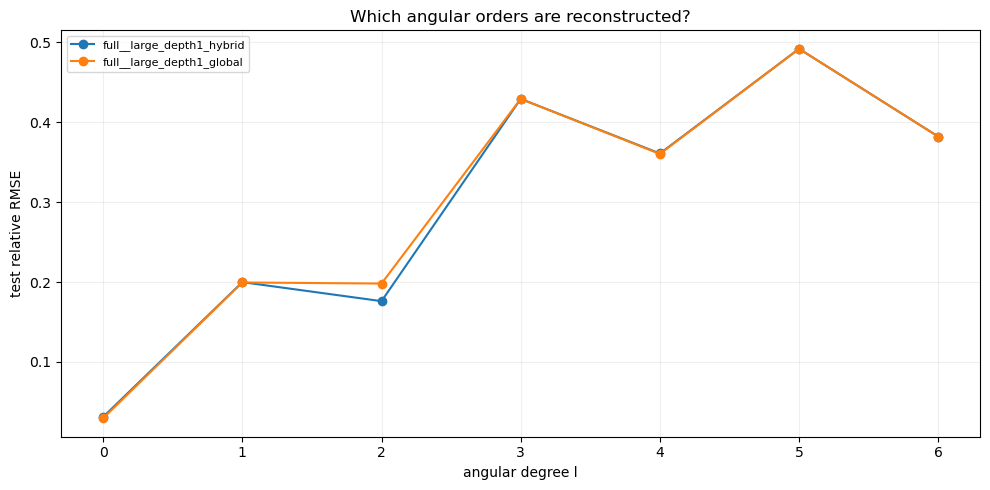

In [26]:
def latent_invariant_descriptor(latent, irreps):
    """Scalars plus all within-irrep Gram entries; invariant but richer than norms."""
    features = []
    for (multiplicity, irrep), slc in zip(irreps, irreps.slices()):
        block = latent[:, slc].reshape(len(latent), multiplicity, irrep.dim)
        if irrep.l == 0:
            features.append(block.squeeze(-1))
        else:
            gram = torch.einsum("bmd,bnd->bmn", block, block) / irrep.dim
            left, right = torch.triu_indices(multiplicity, multiplicity)
            features.append(gram[:, left, right])
    return torch.cat(features, dim=-1)


def coefficient_power_descriptor(coefficients):
    features = []
    for (multiplicity, irrep), slc in zip(MASTER_IRREPS, MASTER_IRREPS.slices()):
        block = coefficients[:, slc].reshape(len(coefficients), multiplicity, irrep.dim)
        if irrep.l == 0:
            features.append(block.squeeze(-1))
        else:
            gram = torch.einsum("brd,bsd->brs", block, block) / irrep.dim
            left, right = torch.triu_indices(multiplicity, multiplicity)
            features.append(gram[:, left, right])
    return torch.cat(features, dim=-1)


def robust_effective_rank(features):
    standard_deviation = features.std(axis=0)
    active = standard_deviation > 1e-10
    if active.sum() <= 1:
        return float(active.sum())
    scaled = StandardScaler().fit_transform(features[:, active])
    eigenvalues = np.maximum(np.linalg.eigvalsh(np.cov(scaled, rowvar=False)), 0)
    return float(eigenvalues.sum() ** 2 / np.square(eigenvalues).sum())


def phase_probe(invariant_features, dataset, seed):
    fit = dataset["split"] != "test"
    test = dataset["split"] == "test"
    probe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5_000, class_weight="balanced", random_state=seed),
    ).fit(invariant_features[fit], dataset["labels"][fit])
    prediction = probe.predict(invariant_features[test])
    return {
        "balanced_accuracy": balanced_accuracy_score(dataset["labels"][test], prediction),
        "macro_F1": f1_score(dataset["labels"][test], prediction, average="macro"),
        "probe": probe,
    }


def equivariance_audit(model, coefficients, seed):
    model = model.to(DEVICE).eval()
    reference = torch.from_numpy(coefficients[:16]).to(DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    rotations = include_reflections(
        random_rotation_matrices(len(reference), DEVICE, generator)
    )
    transformed = rotate_irrep_features(reference, MASTER_IRREPS, rotations)
    with torch.no_grad():
        reference_output, reference_latent = model(reference)
        actual_output, actual_latent = model(transformed)
        expected_output = rotate_irrep_features(reference_output, MASTER_IRREPS, rotations)
        expected_latent = rotate_irrep_features(
            reference_latent, model.latent_irreps, rotations
        )
    model.cpu()
    return {
        "latent_max_abs_error": float((actual_latent - expected_latent).abs().max().item()),
        "output_max_abs_error": float((actual_output - expected_output).abs().max().item()),
    }


def evaluate_artifact(artifact, dataset, coefficients):
    prediction, latent = predict_coefficients_and_latent(
        artifact["model"], coefficients
    )
    test = dataset["split"] == "test"
    train = dataset["split"] == "train"
    errors = np.sqrt(
        np.square(prediction - coefficients).sum(axis=1)
        / np.square(coefficients).sum(axis=1).clip(min=1e-12)
    )
    per_degree = relative_rmse_by_degree(
        torch.from_numpy(prediction[test]), torch.from_numpy(coefficients[test])
    )
    invariant_latent = latent_invariant_descriptor(
        torch.from_numpy(latent), artifact["model"].latent_irreps
    ).numpy()
    probe = phase_probe(invariant_latent, dataset, artifact["seed"] if "seed" in artifact else MAIN_SEED)
    audit = equivariance_audit(artifact["model"], coefficients, MAIN_SEED + 4_000)
    row = {
        "model": artifact["spec"].name,
        "test_global_RRMSE": float(errors[test].mean()),
        "test_global_RRMSE_std": float(errors[test].std()),
        "phase_probe_balanced_accuracy": probe["balanced_accuracy"],
        "phase_probe_macro_F1": probe["macro_F1"],
        "invariant_descriptor_dimension": invariant_latent.shape[1],
        "invariant_descriptor_effective_rank": robust_effective_rank(invariant_latent[train]),
        **audit,
        **{
            f"test_l{degree}_RRMSE": float(values.mean())
            for degree, values in per_degree.items()
        },
    }
    derived = {
        "prediction": prediction,
        "latent": latent,
        "invariant_latent": invariant_latent,
        "errors": errors,
        "probe": probe["probe"],
    }
    return row, derived


final_evaluation_rows, final_derived = [], {}
if RUN_FINALISTS:
    for name, artifact in finalist_artifacts.items():
        row, derived = evaluate_artifact(artifact, dataset, master_coefficients)
        final_evaluation_rows.append(row)
        final_derived[name] = derived
    final_evaluation = pd.DataFrame(final_evaluation_rows).sort_values("test_global_RRMSE")
    display(final_evaluation.round(5))

    degree_columns = [f"test_l{degree}_RRMSE" for degree in range(MASTER_LMAX + 1)]
    fig, ax = plt.subplots(figsize=(10, 5))
    for _, row in final_evaluation.iterrows():
        ax.plot(
            range(MASTER_LMAX + 1), row[degree_columns].to_numpy(float),
            marker="o", label=row["model"]
        )
    ax.set(
        xlabel="angular degree l", ylabel="test relative RMSE",
        title="Which angular orders are reconstructed?"
    )
    ax.set_xticks(range(MASTER_LMAX + 1))
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Multi-seed confirmation

The architecture is selected once using seed 42 validation data.  Additional
seeds repeat only that frozen architecture; they do not reopen model selection.

In [27]:
confirmation_artifacts = {}
if RUN_MULTI_SEED_CONFIRMATION and RUN_FINALISTS:
    for configuration, base_artifact in finalist_artifacts.items():
        for seed in CONFIRMATION_SEEDS:
            if seed == MAIN_SEED:
                artifact = base_artifact
            else:
                seeded_spec = replace(
                    base_artifact["spec"],
                    name=f"{configuration}__seed_{seed}",
                    group="confirmation",
                )
                print(f"\nConfirmation | {configuration} | seed {seed}")
                artifact = train_candidate(
                    seeded_spec, master_coefficients,
                    full_train_indices, full_val_indices,
                    seed, FINAL_EPOCHS, FINAL_PATIENCE,
                    verbose=True,
                )
            confirmation_artifacts[(configuration, seed)] = artifact
    confirmation_rows = []
    for (configuration, seed), artifact in confirmation_artifacts.items():
        row, _ = evaluate_artifact(artifact, dataset, master_coefficients)
        row["configuration"] = configuration
        row["seed"] = seed
        row["validation_selection_score"] = artifact["summary"][
            "validation_selection_score"
        ]
        confirmation_rows.append(row)
    confirmation_results = pd.DataFrame(confirmation_rows)
    display(confirmation_results.round(5))
    confirmation_summary = confirmation_results.groupby("configuration").agg(
        validation_selection_mean=("validation_selection_score", "mean"),
        validation_selection_std=("validation_selection_score", "std"),
        test_RRMSE_mean=("test_global_RRMSE", "mean"),
        test_RRMSE_std=("test_global_RRMSE", "std"),
        phase_accuracy_mean=("phase_probe_balanced_accuracy", "mean"),
        phase_accuracy_std=("phase_probe_balanced_accuracy", "std"),
    ).sort_values("validation_selection_mean")
    display(confirmation_summary.round(5))
    confirmed_winner_configuration = confirmation_summary.index[0]
    print(
        "Three-seed validation winner:", confirmed_winner_configuration
    )
    # Subsequent diagnostics use seed 42 of the aggregate-selected architecture.
    winning_name = confirmed_winner_configuration
    winning_artifact = finalist_artifacts[winning_name]
    winning_spec = winning_artifact["spec"]


Confirmation | full__large_depth1_global | seed 43
  epoch=001 train_RRMSE=1.0935 val_RRMSE=1.0386 selection=1.0263 lr=2.00e-03
  epoch=025 train_RRMSE=0.5791 val_RRMSE=0.5782 selection=0.5335 lr=1.96e-03
  epoch=050 train_RRMSE=0.4218 val_RRMSE=0.4276 selection=0.3959 lr=1.85e-03
  epoch=075 train_RRMSE=0.3928 val_RRMSE=0.3983 selection=0.3622 lr=1.67e-03
  epoch=100 train_RRMSE=0.3810 val_RRMSE=0.3864 selection=0.3505 lr=1.43e-03
  epoch=125 train_RRMSE=0.3751 val_RRMSE=0.3806 selection=0.3447 lr=1.16e-03
  epoch=150 train_RRMSE=0.3716 val_RRMSE=0.3771 selection=0.3413 lr=8.80e-04
  epoch=175 train_RRMSE=0.3692 val_RRMSE=0.3749 selection=0.3392 lr=6.09e-04
  epoch=200 train_RRMSE=0.3676 val_RRMSE=0.3733 selection=0.3377 lr=3.70e-04
  epoch=225 train_RRMSE=0.3666 val_RRMSE=0.3724 selection=0.3368 lr=1.83e-04
  epoch=250 train_RRMSE=0.3662 val_RRMSE=0.3720 selection=0.3364 lr=6.34e-05
  epoch=275 train_RRMSE=0.3660 val_RRMSE=0.3718 selection=0.3362 lr=2.01e-05

Confirmation | full__la

,model,test_global_RRMSE,test_global_RRMSE_std,phase_probe_balanced_accuracy,phase_probe_macro_F1,invariant_descriptor_dimension,invariant_descriptor_effective_rank,latent_max_abs_error,output_max_abs_error,test_l0_RRMSE,test_l1_RRMSE,test_l2_RRMSE,test_l3_RRMSE,test_l4_RRMSE,test_l5_RRMSE,test_l6_RRMSE,configuration,seed,validation_selection_score
0,full__large_depth1_global,0.35926,0.06893,0.98608,0.98624,72,16.78411,0.0,0.0,0.02941,0.19946,0.19810,0.42937,0.36040,0.49208,0.38210,full__large_depth1_global,42,0.33237
1,full__large_depth1_global__seed_43,0.36770,0.06570,0.98617,0.98621,72,14.49738,0.0,0.0,0.02272,0.16464,0.22351,0.42952,0.36454,0.49482,0.39914,full__large_depth1_global,43,0.33622
2,full__large_depth1_global__seed_44,0.36161,0.06968,0.97643,0.97663,72,14.43831,0.0,0.0,0.02052,0.16119,0.17583,0.43035,0.36023,0.49474,0.38900,full__large_depth1_global,44,0.32896
3,full__large_depth1_hybrid,0.35899,0.06882,0.98478,0.98487,72,16.86718,0.0,0.0,0.03106,0.19987,0.17606,0.42936,0.36100,0.49209,0.38218,full__large_depth1_hybrid,42,0.33089
4,full__large_depth1_hybrid__seed_43,0.36732,0.06577,0.98608,0.98624,72,14.76368,0.0,0.0,0.02188,0.16031,0.22940,0.42881,0.36517,0.49484,0.39805,full__large_depth1_hybrid,43,0.33595
5,full__large_depth1_hybrid__seed_44,0.36165,0.06982,0.97643,0.97663,72,14.99993,0.0,0.0,0.02087,0.17655,0.17521,0.42849,0.36021,0.49439,0.38907,full__large_depth1_hybrid,44,0.32975


,validation_selection_mean,validation_selection_std,test_RRMSE_mean,test_RRMSE_std,phase_accuracy_mean,phase_accuracy_std
configuration,,,,,,
full__large_depth1_hybrid,0.33219,0.00330,0.36265,0.00425,0.98243,0.00524
full__large_depth1_global,0.33252,0.00363,0.36285,0.00436,0.98289,0.00560


Three-seed validation winner: full__large_depth1_hybrid


## 10. Equivariance-preserving irrep PCA

Ordinary PCA on raw irrep components breaks equivariance.  Here covariance is
formed only across multiplicity channels and averaged over the $m$ components
of each irrep.  The same channel projection is then applied to every $m$.
This commutes with rotations and provides a post-hoc estimate of how narrow a
learned equivariant bottleneck could be.

,energy_threshold,retained_irrep_channels,retained_scalar_components,test_global_RRMSE
0,0.80,13,69,0.52530
1,0.90,19,105,0.43317
2,0.95,23,123,0.40546
3,0.99,27,143,0.36049


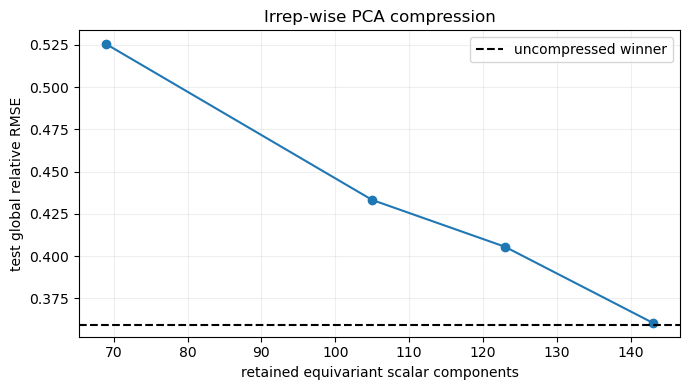

In [28]:
def fit_irrep_pca(latent_train, irreps, energy_threshold):
    projectors = []
    rows = []
    for (multiplicity, irrep), slc in zip(irreps, irreps.slices()):
        block = latent_train[:, slc].reshape(
            len(latent_train), multiplicity, irrep.dim
        )
        mean = torch.zeros(1, multiplicity, 1, dtype=block.dtype)
        covariance_input = block
        if irrep.l == 0:
            mean = block.mean(dim=0, keepdim=True)
            covariance_input = block - mean
        covariance = torch.einsum(
            "bmd,bnd->mn", covariance_input, covariance_input
        ) / max(1, len(block) * irrep.dim)
        eigenvalues, eigenvectors = torch.linalg.eigh(covariance)
        order = torch.argsort(eigenvalues, descending=True)
        eigenvalues = eigenvalues[order].clamp_min(0)
        eigenvectors = eigenvectors[:, order]
        cumulative = torch.cumsum(eigenvalues, dim=0) / eigenvalues.sum().clamp_min(1e-12)
        keep = int(torch.searchsorted(cumulative, energy_threshold).item() + 1)
        projector = eigenvectors[:, :keep] @ eigenvectors[:, :keep].T
        projectors.append((slc, multiplicity, irrep.dim, mean, projector))
        rows.append({
            "degree": irrep.l,
            "available_channels": multiplicity,
            "retained_channels": keep,
            "retained_scalar_components": keep * irrep.dim,
        })
    return projectors, pd.DataFrame(rows)


def apply_irrep_pca(latent, projectors):
    output = latent.clone()
    for slc, multiplicity, irrep_dim, mean, projector in projectors:
        block = latent[:, slc].reshape(len(latent), multiplicity, irrep_dim)
        centered = block - mean.to(block.device)
        projected = torch.einsum("mn,bnd->bmd", projector.to(block.device), centered)
        output[:, slc] = (projected + mean.to(block.device)).flatten(1)
    return output


def decode_latent_numpy(model, latent):
    model = model.to(DEVICE).eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(latent), BATCH_SIZE):
            batch = torch.from_numpy(latent[start:start + BATCH_SIZE]).to(DEVICE)
            outputs.append(model.decode(batch).cpu().numpy())
    model.cpu()
    return np.concatenate(outputs)


irrep_pca_results = pd.DataFrame()
if RUN_EQUIVARIANT_PCA and RUN_FINALISTS:
    winner_info = final_derived[winning_name]
    winner_latent = torch.from_numpy(winner_info["latent"])
    train = dataset["split"] == "train"
    test = dataset["split"] == "test"
    compression_rows = []
    for threshold in IRREP_PCA_ENERGY_LEVELS:
        projectors, channel_table = fit_irrep_pca(
            winner_latent[train], winning_artifact["model"].latent_irreps, threshold
        )
        projected = apply_irrep_pca(winner_latent, projectors).numpy()
        decoded = decode_latent_numpy(winning_artifact["model"], projected)
        error = np.sqrt(
            np.square(decoded - master_coefficients).sum(axis=1)
            / np.square(master_coefficients).sum(axis=1).clip(min=1e-12)
        )
        compression_rows.append({
            "energy_threshold": threshold,
            "retained_irrep_channels": int(channel_table["retained_channels"].sum()),
            "retained_scalar_components": int(channel_table["retained_scalar_components"].sum()),
            "test_global_RRMSE": float(error[test].mean()),
        })
    irrep_pca_results = pd.DataFrame(compression_rows)
    display(irrep_pca_results.round(5))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(
        irrep_pca_results["retained_scalar_components"],
        irrep_pca_results["test_global_RRMSE"], marker="o"
    )
    ax.axhline(
        final_evaluation.set_index("model").loc[winning_name, "test_global_RRMSE"],
        color="black", linestyle="--", label="uncompressed winner"
    )
    ax.set(
        xlabel="retained equivariant scalar components",
        ylabel="test global relative RMSE",
        title="Irrep-wise PCA compression"
    )
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 11. Secondary q-like invariant space

The full equivariant latent must remain available for oriented density
reconstruction.  A separate invariant view is built from scalar channels and
within-irrep Gram matrices.  This generalizes $q_l$ norms by retaining
cross-channel/radial power terms.  PCA is safe *after* these contractions.

,dimension,balanced_accuracy,macro_F1,explained_variance,descriptor
0,2,0.71651,0.71639,0.25722,learned_latent
1,3,0.78822,0.78790,0.32588,learned_latent
2,4,0.81216,0.81169,0.38753,learned_latent
3,6,0.90583,0.90598,0.49545,learned_latent
4,8,0.91992,0.91988,0.57708,learned_latent
5,12,0.93476,0.93489,0.69705,learned_latent
6,16,0.94884,0.94876,0.78143,learned_latent
7,2,0.88041,0.88045,0.23683,input_power_spectrum
8,3,0.88975,0.88977,0.30864,input_power_spectrum
9,4,0.90672,0.90676,0.36207,input_power_spectrum


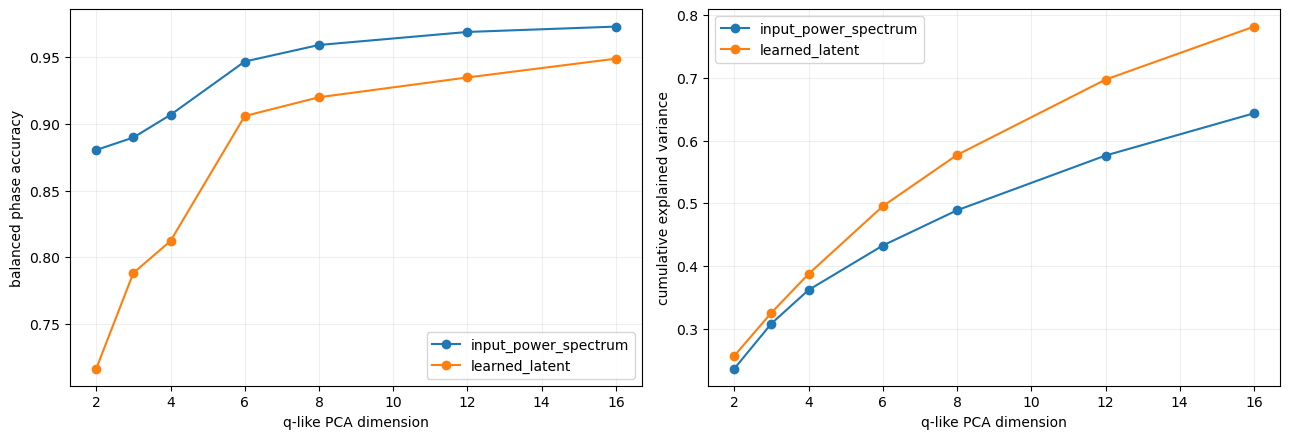

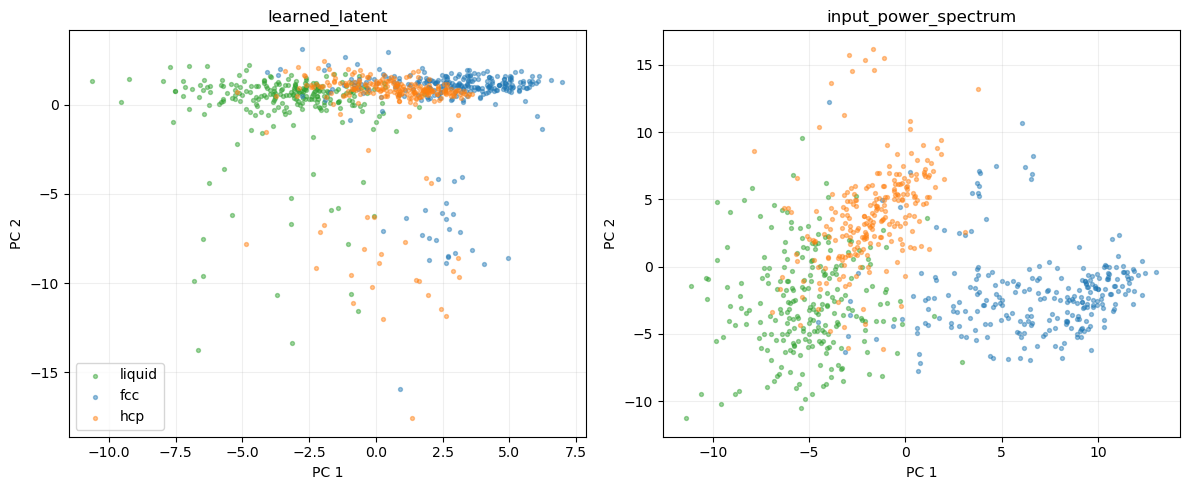

In [29]:
def reduced_q_probe_curve(descriptor, dataset, dimensions, seed):
    train = dataset["split"] == "train"
    fit = dataset["split"] != "test"
    test = dataset["split"] == "test"
    scaler = StandardScaler().fit(descriptor[train])
    scaled = scaler.transform(descriptor)
    max_components = min(descriptor.shape[1], train.sum())
    pca = PCA(n_components=max_components, random_state=seed).fit(scaled[train])
    transformed = pca.transform(scaled)
    rows = []
    for dimension in dimensions:
        if dimension > max_components:
            continue
        probe = LogisticRegression(
            max_iter=5_000, class_weight="balanced", random_state=seed
        ).fit(transformed[fit, :dimension], dataset["labels"][fit])
        prediction = probe.predict(transformed[test, :dimension])
        rows.append({
            "dimension": dimension,
            "balanced_accuracy": balanced_accuracy_score(
                dataset["labels"][test], prediction
            ),
            "macro_F1": f1_score(dataset["labels"][test], prediction, average="macro"),
            "explained_variance": float(
                pca.explained_variance_ratio_[:dimension].sum()
            ),
        })
    return pd.DataFrame(rows), scaler, pca, transformed


q_space_results = pd.DataFrame()
if RUN_Q_SPACE_STUDY and RUN_FINALISTS:
    latent_descriptor = final_derived[winning_name]["invariant_latent"]
    coefficient_descriptor = coefficient_power_descriptor(
        torch.from_numpy(master_coefficients)
    ).numpy()
    frames = []
    q_objects = {}
    for descriptor_name, descriptor in (
        ("learned_latent", latent_descriptor),
        ("input_power_spectrum", coefficient_descriptor),
    ):
        frame, scaler, pca, transformed = reduced_q_probe_curve(
            descriptor, dataset, Q_DIMENSIONS, MAIN_SEED
        )
        frame["descriptor"] = descriptor_name
        frames.append(frame)
        q_objects[descriptor_name] = {
            "scaler": scaler, "pca": pca, "embedding": transformed
        }
    q_space_results = pd.concat(frames, ignore_index=True)
    display(q_space_results.round(5))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for descriptor_name, frame in q_space_results.groupby("descriptor"):
        axes[0].plot(
            frame["dimension"], frame["balanced_accuracy"],
            marker="o", label=descriptor_name
        )
        axes[1].plot(
            frame["dimension"], frame["explained_variance"],
            marker="o", label=descriptor_name
        )
    axes[0].set(xlabel="q-like PCA dimension", ylabel="balanced phase accuracy")
    axes[1].set(xlabel="q-like PCA dimension", ylabel="cumulative explained variance")
    for ax in axes:
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    test = dataset["split"] == "test"
    for ax, descriptor_name in zip(axes, ("learned_latent", "input_power_spectrum")):
        embedding = q_objects[descriptor_name]["embedding"]
        for phase in PHASES:
            mask = test & (dataset["labels"] == LABEL_MAP[phase])
            ax.scatter(
                embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.45,
                color=LABEL_COLORS[phase], label=phase
            )
        ax.set(title=descriptor_name, xlabel="PC 1", ylabel="PC 2")
        ax.grid(alpha=0.2)
    axes[0].legend()
    plt.tight_layout()
    plt.show()

## 12. Noise and missing-neighbor audit

The selected clean model is evaluated without retraining.  The fixed clean
phase probe tests whether its invariant coordinates remain calibrated under
corruption.  A failure here motivates denoising/masked retraining only after
the architecture has been fixed.

,corruption,level,test_global_RRMSE,fixed_clean_probe_balanced_accuracy,standardized_latent_shift
0,noise,0.01,0.36715,0.98480,0.17588
1,noise,0.03,0.42338,0.95123,0.51213
2,noise,0.05,0.50841,0.87072,0.79868
3,noise,0.10,0.73096,0.42203,1.41659
4,mask,0.10,0.45763,0.37051,1.27779
5,mask,0.25,0.55165,0.33333,2.38059
6,mask,0.40,0.67671,0.33333,3.83868


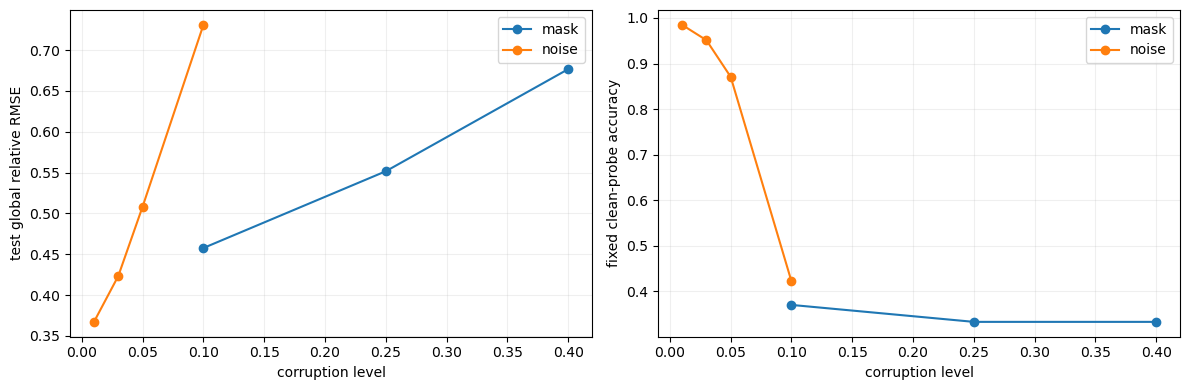

In [30]:
def corrupt_coordinates(clean, corruption, level, generator):
    corrupted = clean.clone()
    observed = torch.ones(len(clean), N_NODES, 1, device=clean.device)
    if corruption == "noise":
        noise = torch.randn(clean.shape, device=clean.device, generator=generator)
        corrupted[:, 1:] += level * noise[:, 1:]
    elif corruption == "mask":
        n_mask = max(1, round(level * N_NEIGHBORS))
        choices = torch.argsort(
            torch.rand(len(clean), N_NEIGHBORS, device=clean.device, generator=generator),
            dim=1,
        )[:, :n_mask] + 1
        observed.scatter_(1, choices.unsqueeze(-1), 0.0)
        corrupted = corrupted * observed
    else:
        raise KeyError(corruption)
    return corrupted, observed


def corrupted_coefficients(dataset, expansion, corruption, level, seed):
    expansion = expansion.to(DEVICE)
    outputs = []
    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        for start in range(0, len(dataset["coordinates"]), BATCH_SIZE):
            clean = torch.from_numpy(
                dataset["coordinates"][start:start + BATCH_SIZE]
            ).to(DEVICE)
            corrupted, observed = corrupt_coordinates(
                clean, corruption, level, generator
            )
            outputs.append(expansion(corrupted, observed).cpu().numpy())
    return np.concatenate(outputs)


corruption_results = pd.DataFrame()
if RUN_CORRUPTION_AUDIT and RUN_FINALISTS:
    clean_info = final_derived[winning_name]
    clean_invariants = clean_info["invariant_latent"]
    clean_probe = phase_probe(clean_invariants, dataset, MAIN_SEED)["probe"]
    test = dataset["split"] == "test"
    rows = []
    for corruption, levels in (("noise", NOISE_LEVELS), ("mask", MASK_LEVELS)):
        for level in levels:
            inputs = corrupted_coefficients(
                dataset, master_expansion, corruption, level,
                MAIN_SEED + int(level * 10_000)
            )
            prediction, latent = predict_coefficients_and_latent(
                winning_artifact["model"], inputs
            )
            target = master_coefficients
            error = np.sqrt(
                np.square(prediction - target).sum(axis=1)
                / np.square(target).sum(axis=1).clip(min=1e-12)
            )
            invariant_latent = latent_invariant_descriptor(
                torch.from_numpy(latent), winning_artifact["model"].latent_irreps
            ).numpy()
            label_prediction = clean_probe.predict(invariant_latent[test])
            rows.append({
                "corruption": corruption,
                "level": level,
                "test_global_RRMSE": float(error[test].mean()),
                "fixed_clean_probe_balanced_accuracy": balanced_accuracy_score(
                    dataset["labels"][test], label_prediction
                ),
                "standardized_latent_shift": float(np.mean(np.sqrt(np.mean(np.square(
                    StandardScaler().fit(clean_invariants[dataset["split"] == "train"]).transform(invariant_latent[test])
                    - StandardScaler().fit(clean_invariants[dataset["split"] == "train"]).transform(clean_invariants[test])
                ), axis=1)))),
            })
    corruption_results = pd.DataFrame(rows)
    display(corruption_results.round(5))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for corruption, frame in corruption_results.groupby("corruption"):
        axes[0].plot(frame["level"], frame["test_global_RRMSE"], marker="o", label=corruption)
        axes[1].plot(
            frame["level"], frame["fixed_clean_probe_balanced_accuracy"],
            marker="o", label=corruption
        )
    axes[0].set(xlabel="corruption level", ylabel="test global relative RMSE")
    axes[1].set(xlabel="corruption level", ylabel="fixed clean-probe accuracy")
    for ax in axes:
        ax.grid(alpha=0.2)
        ax.legend()
    plt.tight_layout()
    plt.show()

## 13. Density reconstruction visualizations

Coefficients are synthesized on a sphere at the radial channel nearest the
median shell.  For each phase, the displayed test sample has median global
reconstruction error.  These maps show angular detail without introducing a
particle assignment or canonical orientation.

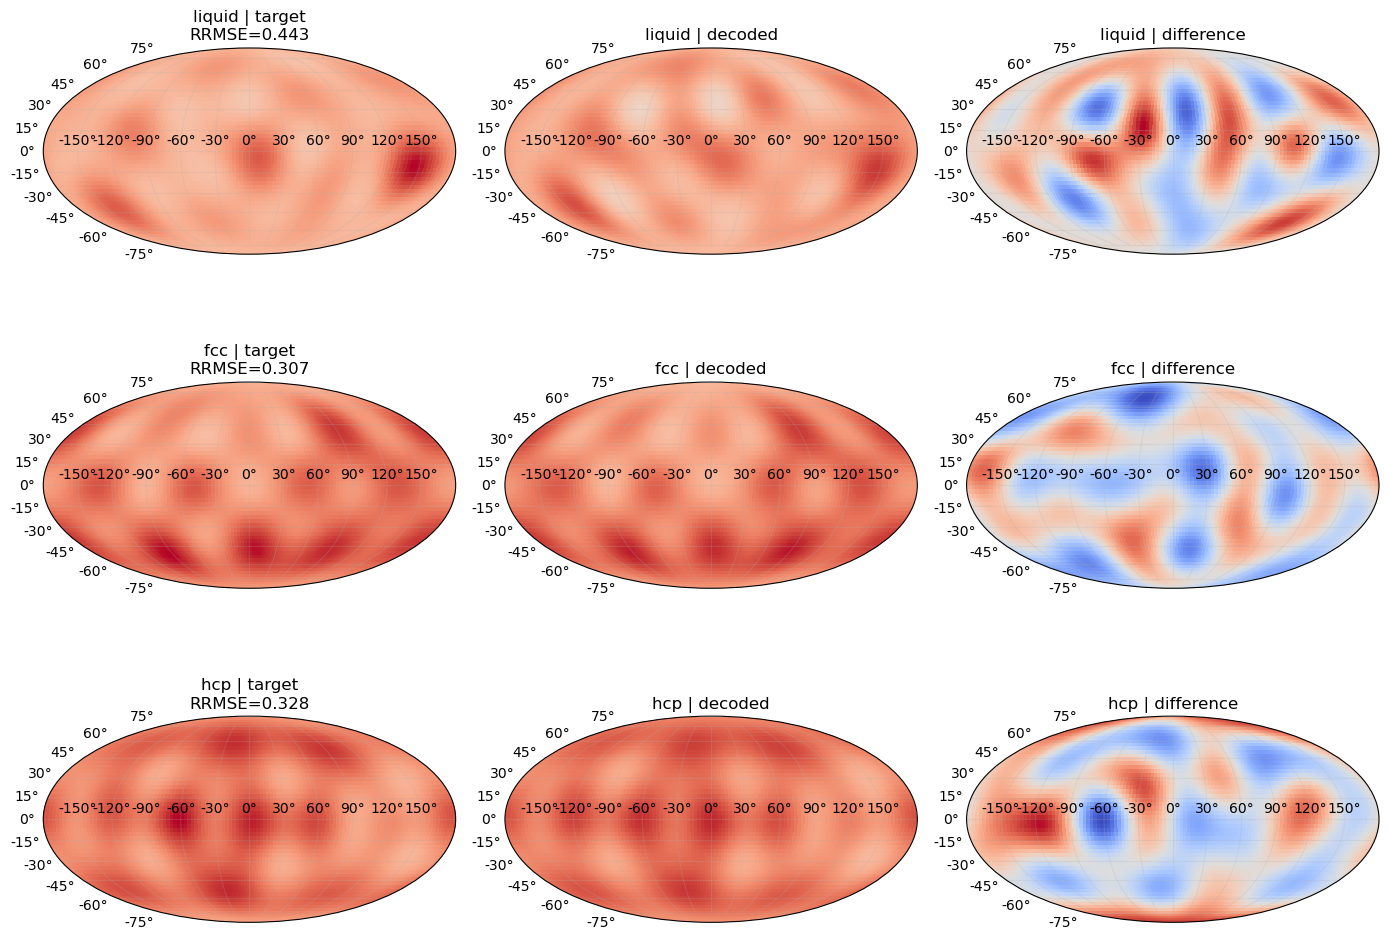

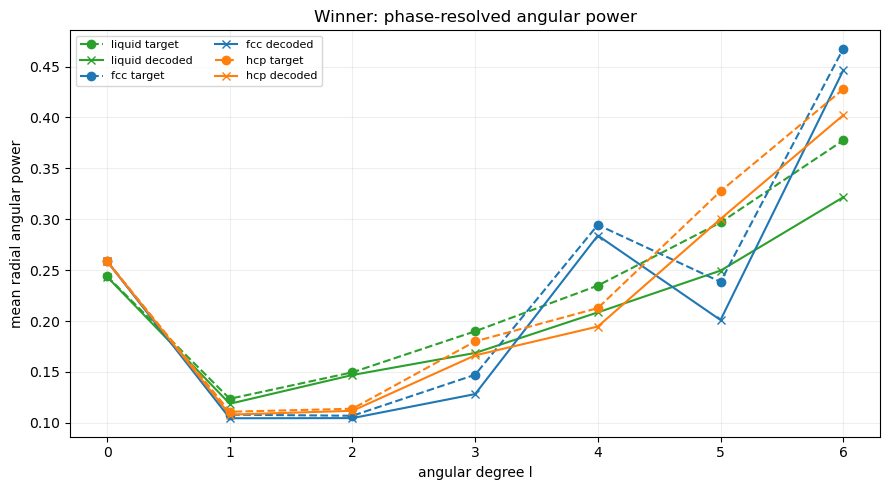

In [31]:
def synthesize_angular_map(coefficients, radial_index, n_latitude=60, n_longitude=120):
    latitude = np.linspace(-np.pi / 2, np.pi / 2, n_latitude)
    longitude = np.linspace(-np.pi, np.pi, n_longitude)
    longitude_grid, latitude_grid = np.meshgrid(longitude, latitude)
    directions = np.stack([
        np.cos(latitude_grid) * np.cos(longitude_grid),
        np.cos(latitude_grid) * np.sin(longitude_grid),
        np.sin(latitude_grid),
    ], axis=-1)
    direction_tensor = torch.from_numpy(directions.astype(np.float32).reshape(-1, 3))
    coefficient_tensor = torch.from_numpy(np.asarray(coefficients, dtype=np.float32))
    density = torch.zeros(len(direction_tensor))
    for (multiplicity, irrep), slc in zip(MASTER_IRREPS, MASTER_IRREPS.slices()):
        block = coefficient_tensor[slc].reshape(multiplicity, irrep.dim)[radial_index]
        harmonics = o3.spherical_harmonics(
            irrep.l, direction_tensor, normalize=True, normalization="component"
        )
        density += harmonics @ block / irrep.dim
    return longitude_grid, latitude_grid, density.numpy().reshape(latitude_grid.shape)


if RUN_FINALISTS:
    winner_prediction = final_derived[winning_name]["prediction"]
    winner_errors = final_derived[winning_name]["errors"]
    radial_index = int(torch.argmin(
        (master_expansion.centers.cpu() - 1.0).abs()
    ).item())
    test = dataset["split"] == "test"
    fig, axes = plt.subplots(
        len(PHASES), 3, figsize=(14, 3.5 * len(PHASES)),
        subplot_kw={"projection": "mollweide"}, squeeze=False
    )
    for row, phase in enumerate(PHASES):
        candidates = np.flatnonzero(test & (dataset["labels"] == LABEL_MAP[phase]))
        chosen = candidates[np.argsort(winner_errors[candidates])[len(candidates) // 2]]
        target_map = synthesize_angular_map(
            master_coefficients[chosen], radial_index
        )
        predicted_map = synthesize_angular_map(
            winner_prediction[chosen], radial_index
        )
        difference = (
            target_map[0], target_map[1], predicted_map[2] - target_map[2]
        )
        shared_limit = max(np.abs(target_map[2]).max(), np.abs(predicted_map[2]).max())
        difference_limit = np.abs(difference[2]).max()
        for column, (title, values, limit) in enumerate((
            ("target", target_map, shared_limit),
            ("decoded", predicted_map, shared_limit),
            ("difference", difference, difference_limit),
        )):
            axes[row, column].pcolormesh(
                values[0], values[1], values[2], shading="auto",
                cmap="coolwarm", vmin=-limit, vmax=limit
            )
            axes[row, column].set_title(
                f"{phase} | {title}" if column else
                f"{phase} | {title}\nRRMSE={winner_errors[chosen]:.3f}"
            )
            axes[row, column].grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    target_power = master_expansion.angular_power(
        torch.from_numpy(master_coefficients[test])
    ).numpy()
    predicted_power = master_expansion.angular_power(
        torch.from_numpy(winner_prediction[test])
    ).numpy()
    test_labels = dataset["labels"][test]
    fig, ax = plt.subplots(figsize=(9, 5))
    for phase in PHASES:
        mask = test_labels == LABEL_MAP[phase]
        color = LABEL_COLORS[phase]
        ax.plot(
            range(MASTER_LMAX + 1), target_power[mask].mean(axis=0),
            color=color, linestyle="--", marker="o", label=f"{phase} target"
        )
        ax.plot(
            range(MASTER_LMAX + 1), predicted_power[mask].mean(axis=0),
            color=color, linestyle="-", marker="x", label=f"{phase} decoded"
        )
    ax.set(
        xlabel="angular degree l", ylabel="mean radial angular power",
        title="Winner: phase-resolved angular power"
    )
    ax.set_xticks(range(MASTER_LMAX + 1))
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 14. Final architecture report and decision rules

The cell below is the notebook's definitive hand-off.  The architecture is
selected only by validation reconstruction.  Among finalists within one
standard error of the best validation score, the smallest model wins.  Phase
quality, test performance, robustness, and compression are reported afterward
as independent evidence.

Interpret the result in this order:

1. Reject the entire run if expansion, latent, or output equivariance is not
   near floating-point tolerance.
2. Require a clear improvement over the zero-output baseline (RRMSE = 1) for
   the global and high-$l$ coefficient errors.
3. Prefer the smallest finalist admitted by the validation one-standard-error
   rule, then use the multi-seed result to judge whether the frozen choice is
   stable enough to exploit.
4. Use irrep-wise PCA to propose a narrower equivariant latent; retrain that
   narrower architecture rather than using post-hoc projection permanently.
5. Choose the q-like dimension at the elbow where phase accuracy and explained
   variance stop improving.  Do not use this invariant projection for oriented
   reconstruction.
6. Only after the clean architecture is frozen should denoising or masked
   reconstruction become new training objectives.

In [32]:
if RUN_FINALISTS:
    winning_model = winning_artifact["model"]
    winner_test_row = final_evaluation.set_index("model").loc[winning_name]
    final_architecture_report = pd.DataFrame([{
        **model_summary(winning_spec),
        "selected_epoch": winning_artifact["summary"]["best_epoch"],
        "validation_selection_score": winning_artifact["summary"]["validation_selection_score"],
        "validation_selection_standard_error": winning_artifact["summary"]["validation_selection_standard_error"],
        "validation_global_RRMSE": winning_artifact["summary"]["validation_global_RRMSE"],
        "test_global_RRMSE": winner_test_row["test_global_RRMSE"],
        "phase_probe_balanced_accuracy": winner_test_row["phase_probe_balanced_accuracy"],
        "latent_max_abs_error": winner_test_row["latent_max_abs_error"],
        "output_max_abs_error": winner_test_row["output_max_abs_error"],
    }])
    display(final_architecture_report.T.rename(columns={0: "selected_value"}))
    print("\nSelected latent irreps:", winning_model.latent_irreps)
    if not irrep_pca_results.empty:
        print("\nEquivariant compression candidates:")
        display(irrep_pca_results.round(5))
    if not q_space_results.empty:
        best_q = q_space_results.sort_values(
            ["descriptor", "balanced_accuracy", "dimension"],
            ascending=[True, False, True],
        ).groupby("descriptor", as_index=False).first()
        print("\nBest tested q-like dimensions:")
        display(best_q.round(5))

,selected_value
name,full__large_depth1_hybrid
group,finalist
input_lmax,6
input_radial_channels,8
width,large
block_type,hybrid
depth,1
loss_type,hybrid
latent_regularization,0.0
input_dimension,392



Selected latent irreps: 12x0e+6x1o+6x2e+3x3o+3x4e+2x5o+2x6e

Equivariant compression candidates:


,energy_threshold,retained_irrep_channels,retained_scalar_components,test_global_RRMSE
0,0.80,13,69,0.52530
1,0.90,19,105,0.43317
2,0.95,23,123,0.40546
3,0.99,27,143,0.36049



Best tested q-like dimensions:


,descriptor,dimension,balanced_accuracy,macro_F1,explained_variance
0,input_power_spectrum,16,0.97287,0.97278,0.64342
1,learned_latent,16,0.94884,0.94876,0.78143
